In [1]:
# Installation des bibliothèques nécessaires:
!pip install paho-mqtt numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 749.4 kB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ===================================================================
# SCRIPT D'ENTRAÎNEMENT COMPLET POUR LE SCÉNARIO 3
# ===================================================================

# Importation des bibliothèques
import paho.mqtt.client as mqtt
import time
import random
import csv
import sys
import numpy as np
import os
import pickle

# ===================================================================
# BLOC 1 : CONFIGURATION POUR GOOGLE DRIVE
# ===================================================================
# Ce chemin doit correspondre au dossier réé sur votre Drive.
try:
    PROJECT_PATH = '/content/drive/MyDrive/Mon_Projet_RL/'
    if not os.path.exists(PROJECT_PATH):
        print(f"ERREUR : Le dossier de projet '{PROJECT_PATH}' est introuvable.")
        print("Veuillez vérifier que votre Google Drive est monté et que le dossier existe.")
        sys.exit()
except Exception as e:
    print(f"Une erreur est survenue lors de la configuration des chemins : {e}")
    sys.exit()
# ===================================================================

# --- CONFIGURATION MQTT ET SUJETS ---
BROKER_ADDRESS = "broker.hivemq.com"
BROKER_PORT = 1883
TOPIC_ARRIVAL = "cupcarbon/linda/simulator/entry"
TOPIC_EXIT = "cupcarbon/linda/simulator/exit"
TOPIC_ACTION = "cupcarbon/linda/simulator/action"
TOPIC_CAR = "cupcarbon/linda/realparking/car"
TOPIC_LIGHT = "cupcarbon/linda/realparking/light"

# --- VARIABLES D'ENVIRONNEMENT ET PARAMÈTRES ---
TOTAL_SPOTS = 150
SPOTS_PER_FLOOR = 50
OCCUPANCY_THRESHOLD = 25
ENERGY_PER_LED_WH_PER_MIN = 0.1
parking_spots_occupied = {}
all_spots = [f"{p}:{s}" for p in range(1, 4) for s in range(1, 51)]
simulation_data = [] # Uniquement pour le rapport final de la dernière simulation
q_table = {}
actions_map = {0: "assign_floor_1", 1: "assign_floor_2", 2: "assign_floor_3"}
num_actions = len(actions_map)
learning_rate = 0.1
discount_factor = 0.9
epsilon = 0.8
last_event_time = None
total_energy_consumed_wh = 0.0
total_reward_current_simulation = 0.0
failed_assignments_count = 0
occupancy_per_floor = {1: 0, 2: 0, 3: 0}
light_status_per_floor = {1: 0, 2: 0, 3: 0}

# ===================================================================
# BLOC 2 : DÉFINITION DES CHEMINS COMPLETS SUR LE DRIVE
# ===================================================================
Q_TABLE_FILE = os.path.join(PROJECT_PATH, 'q_table_final.pkl')
EPSILON_FILE = os.path.join(PROJECT_PATH, 'epsilon_value.pkl')
TRAINING_PROGRESS_FILE = os.path.join(PROJECT_PATH, 'training_progress.csv')
FINAL_REPORT_FILE = os.path.join(PROJECT_PATH, 'simulation_report_last_episode.csv')
# ===================================================================

# Chargement de la Q-table depuis le Drive
try:
    if os.path.exists(Q_TABLE_FILE):
        with open(Q_TABLE_FILE, 'rb') as f: q_table = pickle.load(f)
        print(f"🧠 Q-table chargée depuis le Drive ({len(q_table)} états).")
except Exception as e: print(f"⚠️ Q-table non chargée : {e}.")

# Chargement d'epsilon depuis le Drive
try:
    if os.path.exists(EPSILON_FILE):
        with open(EPSILON_FILE, 'rb') as f: epsilon = pickle.load(f)
        print(f"📉 Epsilon chargé depuis le Drive : {epsilon:.4f}")
    else:
        print(f"🆕 Epsilon par défaut : {epsilon:.4f}")
except Exception as e: print(f"⚠️ Epsilon non chargé : {e}.")

# --- FONCTIONS ---

def on_connect(client, userdata, flags, rc, properties):
    if rc == 0:
        print("✅ Connecté à MQTT avec succès.")
        client.subscribe(TOPIC_ARRIVAL)
        client.subscribe(TOPIC_EXIT)
        client.subscribe(TOPIC_ACTION)
        print(f"📡 Abonné aux sujets.")
    else:
        print(f"❌ Échec de la connexion à MQTT. Code: {rc}")
        sys.exit()

def get_state():
    occ1_discrete = min(9, occupancy_per_floor[1] // (SPOTS_PER_FLOOR // 10))
    occ2_discrete = min(9, occupancy_per_floor[2] // (SPOTS_PER_FLOOR // 10))
    occ3_discrete = min(9, occupancy_per_floor[3] // (SPOTS_PER_FLOOR // 10))
    return (occ1_discrete, occ2_discrete, occ3_discrete)

def choose_action(state):
    if state not in q_table:
        q_table[state] = np.zeros(num_actions)
    available_actions_indices = [i for i in range(num_actions) if occupancy_per_floor[i+1] < SPOTS_PER_FLOOR]
    if not available_actions_indices: return None
    if random.uniform(0, 1) < epsilon:
        return random.choice(available_actions_indices)
    else:
        q_values_for_state = q_table[state]
        masked_q_values = {i: q_values_for_state[i] for i in available_actions_indices}
        return max(masked_q_values, key=masked_q_values.get)

def update_q_table(state, action_index, reward, next_state):
    if state not in q_table: q_table[state] = np.zeros(num_actions)
    if next_state not in q_table: q_table[next_state] = np.zeros(num_actions)
    q_value = q_table[state][action_index]
    max_next_q = np.max(q_table[next_state])
    new_q_value = q_value + learning_rate * (reward + discount_factor * max_next_q - q_value)
    q_table[state][action_index] = new_q_value

def get_reward(is_optimal_choice, is_critical_error):
    if is_critical_error: return -50
    return 1 if is_optimal_choice else -10

def update_energy_consumption():
    global last_event_time, total_energy_consumed_wh
    if last_event_time is None:
        last_event_time = time.time()
        return
    time_elapsed_minutes = (time.time() - last_event_time) / 60
    leds_on = sum((SPOTS_PER_FLOOR - occupancy_per_floor[floor]) for floor in range(1, 4) if light_status_per_floor[floor] == 1)
    energy_consumed_interval = leds_on * ENERGY_PER_LED_WH_PER_MIN * time_elapsed_minutes
    total_energy_consumed_wh += energy_consumed_interval
    last_event_time = time.time()

def update_training_metrics():
    csv_filename = TRAINING_PROGRESS_FILE
    file_exists = os.path.isfile(csv_filename) and os.path.getsize(csv_filename) > 0
    with open(csv_filename, mode='a', newline='') as file:
        writer = csv.writer(file)
        if not file_exists:
            writer.writerow(['simulation_id', 'total_reward', 'total_energy_wh', 'failed_assignments', 'occupancy_variance', 'epsilon'])

        last_id = 0
        if file_exists:
            with open(csv_filename, 'r') as f_read:
                lines = f_read.readlines()
                if len(lines) > 1: last_id = int(lines[-1].split(',')[0])

        occupancy_variance = np.var(list(occupancy_per_floor.values()))
        writer.writerow([last_id + 1, f'{total_reward_current_simulation:.2f}', f'{total_energy_consumed_wh:.2f}', failed_assignments_count, f'{occupancy_variance:.2f}', f'{epsilon:.4f}'])
    print(f"📊 Métriques de l'épisode #{last_id + 1} sauvegardées sur Google Drive.")

def toggle_floor_lights(client, floor, turn_on):
    action_str = "Allumage" if turn_on else "Extinction"
    print(f"  💡 {action_str} des LED pour l'étage {floor}.")
    for s in range(1, SPOTS_PER_FLOOR + 1):
        spot_id = f"{floor}:{s}"
        if spot_id not in parking_spots_occupied:
            status = 1 if turn_on else 0
            client.publish(TOPIC_LIGHT, f"{floor}:{s}:{status}")

def on_message(client, userdata, msg):
    global parking_spots_occupied, total_reward_current_simulation, failed_assignments_count, epsilon, total_energy_consumed_wh, simulation_data

    update_energy_consumption()
    payload = msg.payload.decode()

    if msg.topic == TOPIC_ARRIVAL:
        current_state = get_state()
        action_index = choose_action(current_state)
        if action_index is None:
            failed_assignments_count += 1
            return

        assigned_floor = action_index + 1
        valid_floors = {k:v for k,v in occupancy_per_floor.items() if v < SPOTS_PER_FLOOR}
        optimal_floor = min(valid_floors, key=valid_floors.get) if valid_floors else assigned_floor
        is_optimal_choice = (assigned_floor == optimal_floor)

        available_spots_on_floor = [s for s in all_spots if s.startswith(f"{assigned_floor}:") and s not in parking_spots_occupied]
        spot_id = random.choice(available_spots_on_floor)
        parking_spots_occupied[spot_id] = payload
        occupancy_per_floor[assigned_floor] += 1
        platform, place = spot_id.split(':')
        client.publish(TOPIC_CAR, f"{platform}:{place}:1")
        client.publish(TOPIC_LIGHT, f"{platform}:{place}:0")

        reward = get_reward(is_optimal_choice, is_critical_error=False)
        total_reward_current_simulation += reward
        next_state = get_state()
        update_q_table(current_state, action_index, reward, next_state)

        if occupancy_per_floor[assigned_floor] >= OCCUPANCY_THRESHOLD and light_status_per_floor[assigned_floor] == 0:
            toggle_floor_lights(client, assigned_floor, turn_on=True)
            light_status_per_floor[assigned_floor] = 1

        simulation_data.append({'Timestamp': time.strftime('%Y-%m-%d %H:%M:%S'), 'Event Type': 'ARRIVAL', 'Assigned Spot': spot_id})

    elif msg.topic == TOPIC_EXIT:
        spot_id = next((spot for spot, car in parking_spots_occupied.items() if car == payload), None)
        if not spot_id: return
        platform, place = map(int, spot_id.split(':'))
        del parking_spots_occupied[spot_id]
        occupancy_per_floor[platform] -= 1
        client.publish(TOPIC_CAR, f"{platform}:{place}:0")
        light_status = 1 if light_status_per_floor[platform] == 1 else 0
        client.publish(TOPIC_LIGHT, f"{platform}:{place}:{light_status}")
        if occupancy_per_floor[platform] < OCCUPANCY_THRESHOLD and light_status_per_floor[platform] == 1:
            toggle_floor_lights(client, platform, turn_on=False)
            light_status_per_floor[platform] = 0

        simulation_data.append({'Timestamp': time.strftime('%Y-%m-%d %H:%M:%S'), 'Event Type': 'EXIT', 'Assigned Spot': spot_id})

    elif msg.topic == TOPIC_ACTION and payload == "STOP_SIMULATION":
        print("\n\n🏁 Message de fin de simulation reçu.")
        update_energy_consumption()
        update_training_metrics()

        epsilon = max(0.1, epsilon * 0.99)
        print(f"📉 Epsilon mis à jour : {epsilon:.4f}")

        # Sauvegarde de la mémoire sur le Drive
        try:
            with open(Q_TABLE_FILE, 'wb') as f: pickle.dump(q_table, f)
            print(f"💾 Q-table sauvegardée sur Google Drive.")
        except Exception as e: print(f"❌ Erreur sauvegarde Q-table : {e}")
        try:
            with open(EPSILON_FILE, 'wb') as f: pickle.dump(epsilon, f)
            print(f"💾 Epsilon sauvegardé sur Google Drive.")
        except Exception as e: print(f"❌ Erreur sauvegarde epsilon : {e}")

        # Écriture d'un rapport final pour cet épisode (qui sera écrasé au prochain)
        try:
            with open(FINAL_REPORT_FILE, mode='w', newline='') as file:
                writer = csv.writer(file)
                writer.writerow(['Timestamp', 'Event Type', 'Assigned Spot'])
                for row in simulation_data:
                    writer.writerow([row['Timestamp'], row['Event Type'], row['Assigned Spot']])
            print(f"📄 Rapport de l'épisode sauvegardé dans '{FINAL_REPORT_FILE}'.")
        except Exception as e:
            print(f"❌ Erreur lors de l'écriture du rapport final : {e}")

        client.loop_stop()
        client.disconnect()
        print("Déconnecté. Fin du script.")

# --- PROGRAMME PRINCIPAL ---
if __name__ == "__main__":
    client = mqtt.Client(mqtt.CallbackAPIVersion.VERSION2)
    client.on_connect = on_connect
    client.on_message = on_message
    try:
        client.connect(BROKER_ADDRESS, BROKER_PORT, 60)
        client.loop_forever()
    except KeyboardInterrupt:
        print("\nℹ️ Arrêt du script.")
    finally:
        if client.is_connected(): client.disconnect()
        print("Déconnecté.")

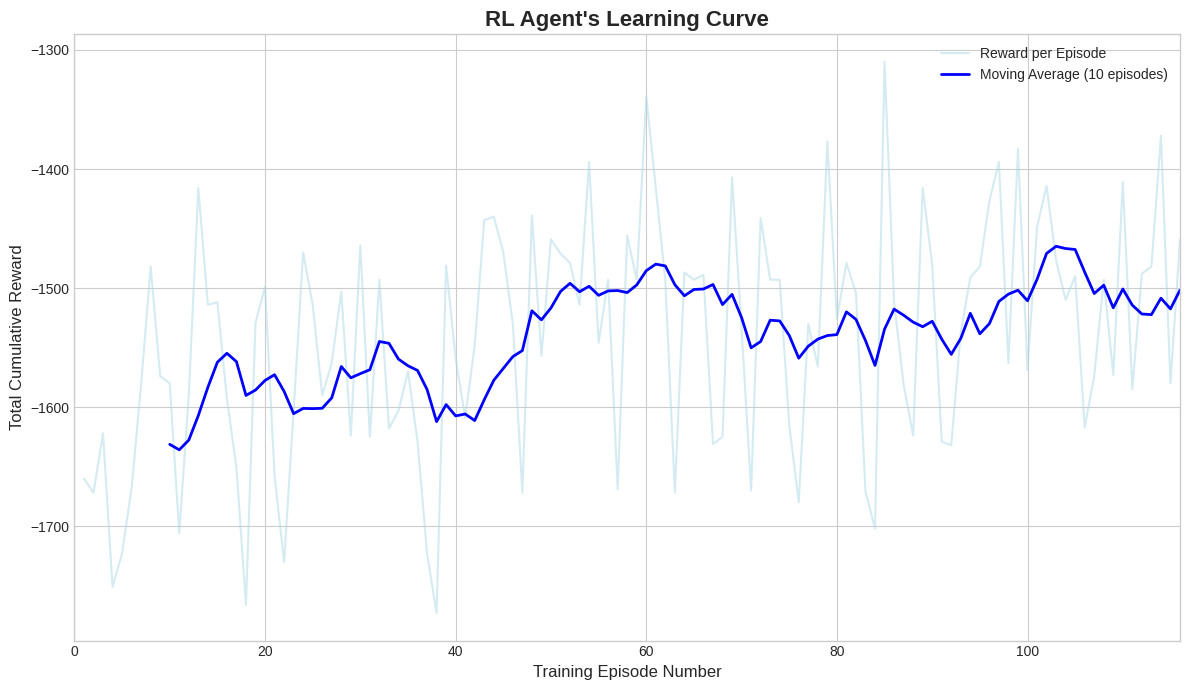

In [4]:
# ===================================================================
# VISUALIZATION CELL: RL AGENT'S LEARNING CURVE
# ===================================================================

# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- PARAMETERS ---
# Path to your project folder on Google Drive
PROJECT_PATH = '/content/drive/MyDrive/Mon_Projet_RL/'
# Name of the file containing the training history
TRAINING_FILE = os.path.join(PROJECT_PATH, 'training_progress.csv')
# Window size for the moving average (to smooth the curve)
MOVING_AVERAGE_WINDOW = 10

# --- DATA READING AND PROCESSING ---
if not os.path.exists(TRAINING_FILE):
    print(f"ERROR: The file '{TRAINING_FILE}' was not found.")
else:
    try:
        # Read the CSV file using pandas
        df_progress = pd.read_csv(TRAINING_FILE)

        # Ensure the necessary columns exist
        if 'simulation_id' in df_progress.columns and 'total_reward' in df_progress.columns:

            # Calculate the moving average to smooth out fluctuations
            df_progress['reward_moving_avg'] = df_progress['total_reward'].rolling(window=MOVING_AVERAGE_WINDOW).mean()

            # --- CHART CREATION ---
            plt.style.use('seaborn-v0_8-whitegrid') # Aesthetic style
            fig, ax = plt.subplots(figsize=(12, 7)) # Create a well-sized figure

            # 1. Plot the raw reward (volatile) with low opacity
            ax.plot(df_progress['simulation_id'], df_progress['total_reward'],
                    color='lightblue', alpha=0.5, label='Reward per Episode')

            # 2. Plot the moving average (the trend) on top, more visible
            ax.plot(df_progress['simulation_id'], df_progress['reward_moving_avg'],
                    color='blue', linewidth=2, label=f'Moving Average ({MOVING_AVERAGE_WINDOW} episodes)')

            # Titles and labels (in English)
            ax.set_title("RL Agent's Learning Curve", fontsize=16, fontweight='bold')
            ax.set_xlabel('Training Episode Number', fontsize=12)
            ax.set_ylabel('Total Cumulative Reward', fontsize=12)
            ax.legend()
            ax.grid(True)

            # Limit the X-axis to the number of episodes
            ax.set_xlim(0, len(df_progress))

            # Display the chart
            plt.tight_layout()
            plt.show()

        else:
            print("ERROR: 'simulation_id' or 'total_reward' columns are missing in the file.")

    except Exception as e:
        print(f"An error occurred while creating the chart: {e}")

Fichier CSV chargé avec succès.
Graphique sauvegardé sous : 'kpi_evolution.png'


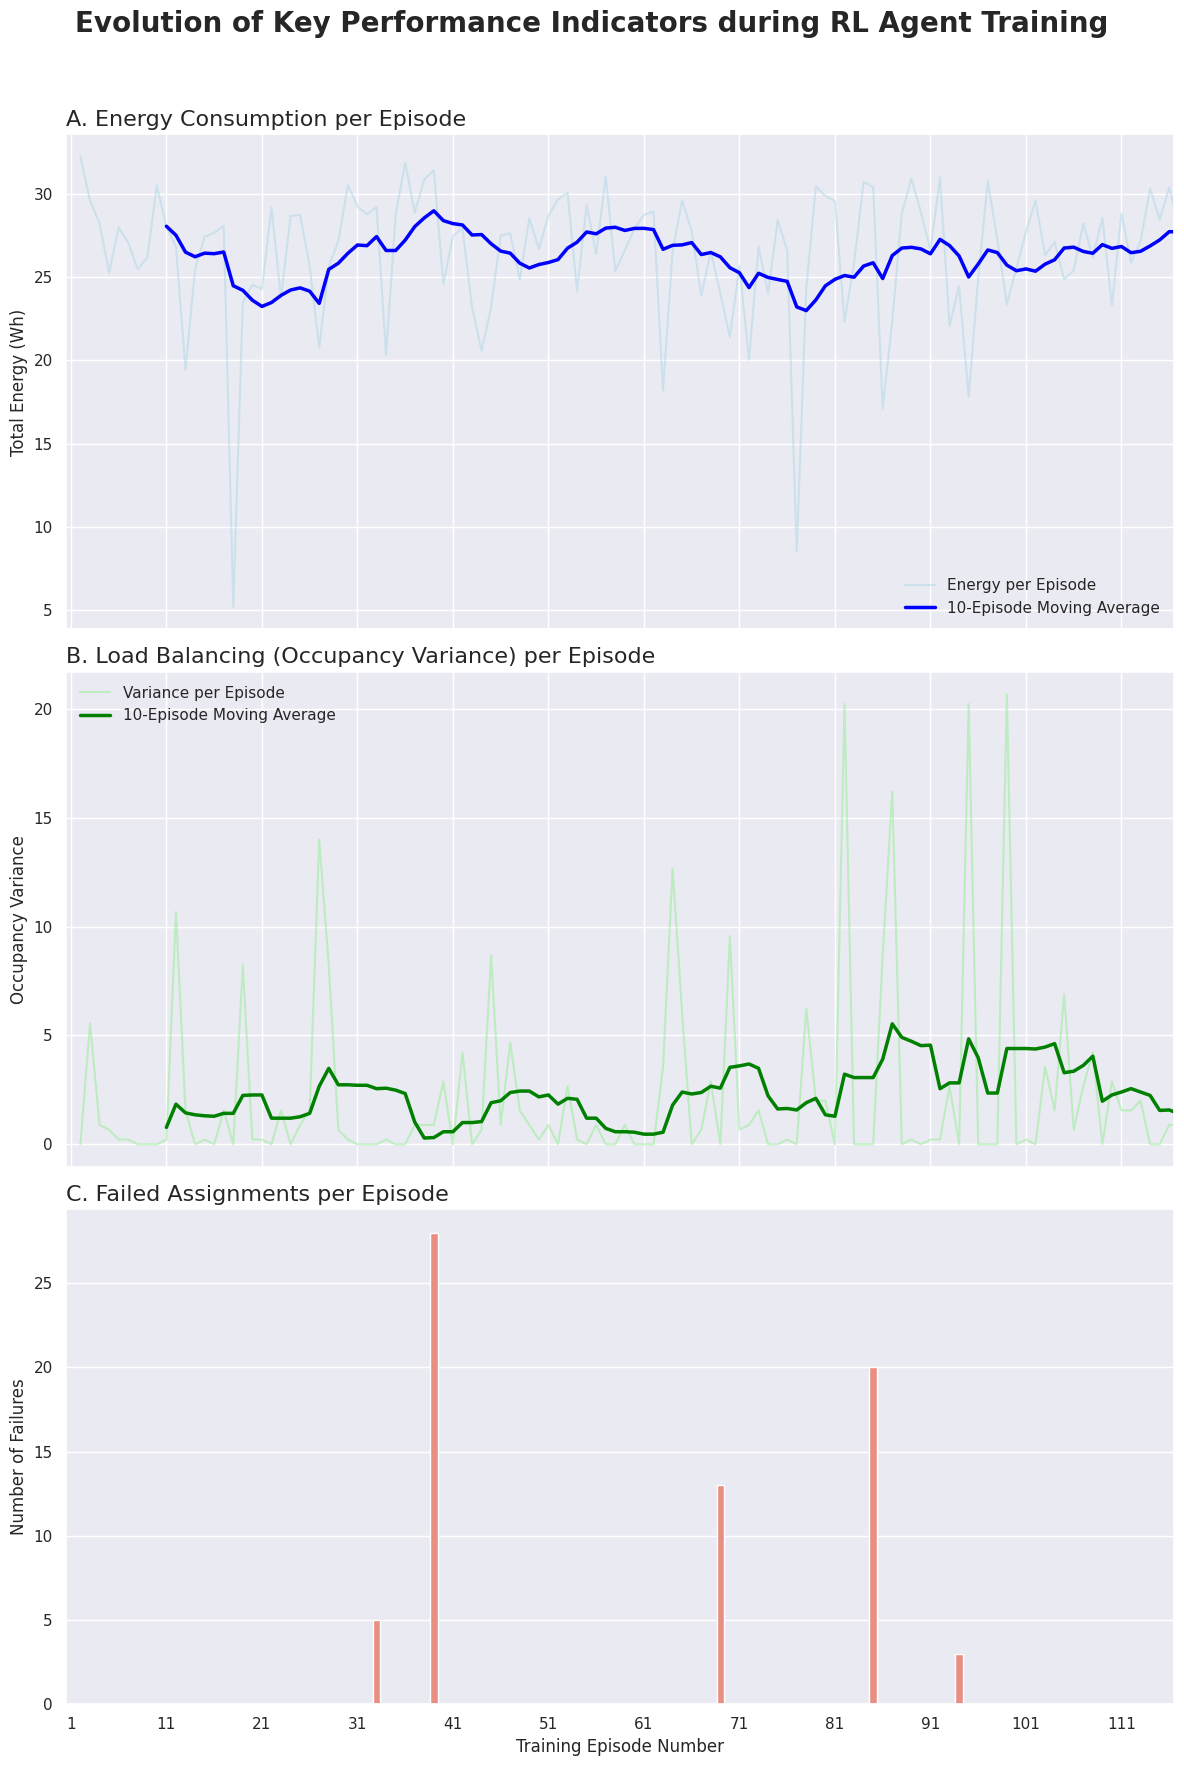

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---

CSV_FILE_PATH = '/content/drive/MyDrive/Mon_Projet_RL/training_progress.csv'

OUTPUT_IMAGE_PATH = 'kpi_evolution.png'
ROLLING_WINDOW = 10 # Pour la moyenne mobile

# --- Chargement et préparation des données ---
try:
    df = pd.read_csv(CSV_FILE_PATH)
    print("Fichier CSV chargé avec succès.")
except FileNotFoundError:
    print(f"ERREUR : Le fichier '{CSV_FILE_PATH}' est introuvable. Veuillez le placer dans le bon répertoire.")
    exit()

# Calcul de la moyenne mobile pour la récompense, l'énergie et la variance
df['reward_ma'] = df['total_reward'].rolling(window=ROLLING_WINDOW).mean()
df['energy_ma'] = df['total_energy_wh'].rolling(window=ROLLING_WINDOW).mean()
df['variance_ma'] = df['occupancy_variance'].rolling(window=ROLLING_WINDOW).mean()

# --- Création de la figure composite ---
sns.set_theme(style="darkgrid")
fig, axs = plt.subplots(3, 1, figsize=(12, 18), sharex=True)
fig.suptitle('Evolution of Key Performance Indicators during RL Agent Training', fontsize=20, weight='bold')

# 1. Graphique de la Consommation d'Énergie
sns.lineplot(ax=axs[0], x='simulation_id', y='total_energy_wh', data=df, color='lightblue', label='Energy per Episode', alpha=0.5)
sns.lineplot(ax=axs[0], x='simulation_id', y='energy_ma', data=df, color='blue', label=f'{ROLLING_WINDOW}-Episode Moving Average', linewidth=2.5)
axs[0].set_title('A. Energy Consumption per Episode', fontsize=16, loc='left')
axs[0].set_ylabel('Total Energy (Wh)')
axs[0].legend()

# 2. Graphique de la Variance d'Occupation (Équilibrage)
sns.lineplot(ax=axs[1], x='simulation_id', y='occupancy_variance', data=df, color='lightgreen', label='Variance per Episode', alpha=0.5)
sns.lineplot(ax=axs[1], x='simulation_id', y='variance_ma', data=df, color='green', label=f'{ROLLING_WINDOW}-Episode Moving Average', linewidth=2.5)
axs[1].set_title('B. Load Balancing (Occupancy Variance) per Episode', fontsize=16, loc='left')
axs[1].set_ylabel('Occupancy Variance')
axs[1].legend()

# 3. Graphique des Affectations Échouées
sns.barplot(ax=axs[2], x='simulation_id', y='failed_assignments', data=df, color='salmon')
axs[2].set_title('C. Failed Assignments per Episode', fontsize=16, loc='left')
axs[2].set_ylabel('Number of Failures')
axs[2].set_xlabel('Training Episode Number', fontsize=12)
# Optionnel : n'afficher les xticks que tous les 10 épisodes pour plus de lisibilité
axs[2].set_xticks(range(0, len(df), 10))
axs[2].set_xticklabels(range(1, len(df)+1, 10))


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(OUTPUT_IMAGE_PATH, dpi=300)
print(f"Graphique sauvegardé sous : '{OUTPUT_IMAGE_PATH}'")
plt.show()

ERREUR : Le fichier 'training_progress.csv' est introuvable.
Graphique de la décroissance d'epsilon sauvegardé sous : 'epsilon_decay.png'


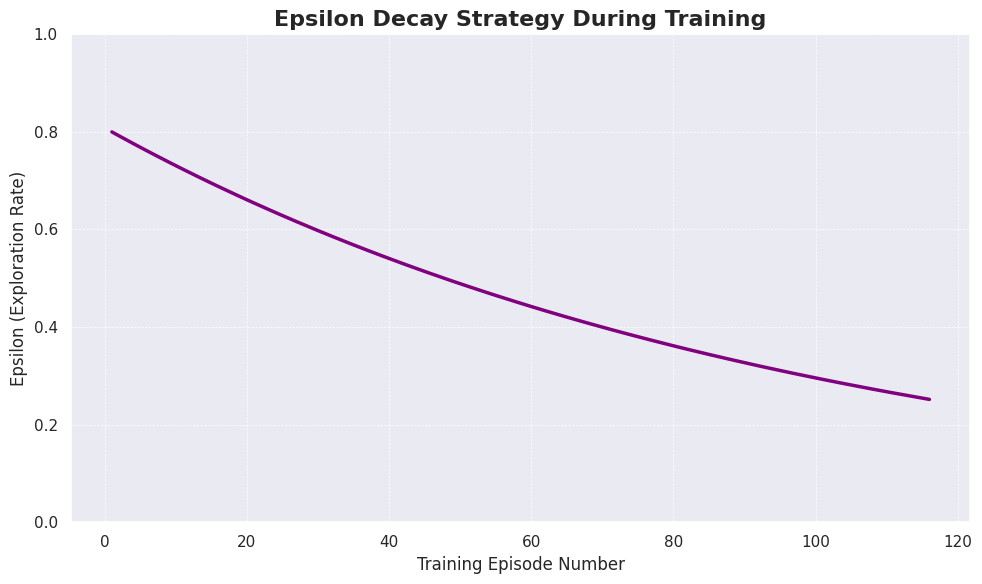

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
CSV_FILE_PATH = 'training_progress.csv'
OUTPUT_IMAGE_PATH = 'epsilon_decay.png'

# --- Chargement des données ---
try:
    df = pd.read_csv(CSV_FILE_PATH)
    print("Fichier CSV chargé avec succès.")
except FileNotFoundError:
    print(f"ERREUR : Le fichier '{CSV_FILE_PATH}' est introuvable.")
    exit()

# --- Création du graphique de décroissance d'Epsilon ---
sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 6))

sns.lineplot(x='simulation_id', y='epsilon', data=df, color='purple', linewidth=2.5)

plt.title('Epsilon Decay Strategy During Training', fontsize=16, weight='bold')
plt.xlabel('Training Episode Number', fontsize=12)
plt.ylabel('Epsilon (Exploration Rate)', fontsize=12)
plt.ylim(0, 1.0) # Epsilon is a probability, so its range is [0, 1]
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_IMAGE_PATH, dpi=300)
print(f"Graphique de la décroissance d'epsilon sauvegardé sous : '{OUTPUT_IMAGE_PATH}'")
plt.show()